## Project overview
You are recently hired as a data scientist for a video streaming company. This company recently lossing more customers. The stakeholders have decided to use data science to khow the reason and figure out the solution.

## 1. Define Scope of the project
#### Problem statement:
A video streming company is experiencing a decline in premium subscription, with significant number of customers canceling their subscription plans. The goal is to understand the factors contributing customers churn and develop strategies.

#### Objective and Goals
Analyze customer behaviour and usage pattern to identify main factors contributing customers churn

#### Data requirements
Gender and demographic = Age, sex, location
Usage = How much time they have spent, what are they search, how much time they spent on each video, how many times they open the app in a day (daily active users)
Subscription plan: How frequent they purchase the plan, how many times they come to the subscription landing page
Engagement with add-ons

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
df = pd.read_csv("../data/Streaming.csv")

df.sample(2)

,Customer_ID,Age,Gender,Subscription_Length,Region,Payment_Method,Support_Tickets_Raised,Satisfaction_Score,Discount_Offered,Last_Activity,Monthly_Spend,Churned
995,CUST000996,60.0,Female,39,South,PayPal,0,10.0,5.41,69,59.85,0
4601,CUST004602,47.0,Female,23,East,Debit Card,2,2.0,5.38,159,32.71,1


### Remove data set which we dont need

In [34]:
df.drop(columns=['Subscription_Length', 'Payment_Method'], inplace=True)

df.sample(2)

,Customer_ID,Age,Gender,Region,Support_Tickets_Raised,Satisfaction_Score,Discount_Offered,Last_Activity,Monthly_Spend,Churned
2783,CUST002784,NaN,Male,East,2,1.0,9.65,30,40.03,1
3295,CUST003296,67.0,Male,South,2,9.0,15.75,325,47.88,1


#### Understand the datatypes of the features

In [35]:
df.dtypes

Customer_ID                   str
Age                       float64
Gender                        str
Region                        str
Support_Tickets_Raised      int64
Satisfaction_Score        float64
Discount_Offered          float64
Last_Activity               int64
Monthly_Spend             float64
Churned                     int64
dtype: object

 float32 vs float64 (short + clear)

float32
- 32 bits (4 bytes)
- less precision (~6–7 decimal digits)
- uses less memory, faster

float64:
- 64 bits (8 bytes)
- higher precision (~15–16 decimal digits)
- default in Python, more accurate

#### How to change data type if required

In [36]:
df['Age'].astype('float32')

0       56.0
1       69.0
2       46.0
3       32.0
4       60.0
        ... 
4995    24.0
4996    66.0
4997    26.0
4998    53.0
4999    36.0
Name: Age, Length: 5000, dtype: float32

Handle Missing data

In [37]:
# Check for missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer_ID             5000 non-null   str    
 1   Age                     4500 non-null   float64
 2   Gender                  5000 non-null   str    
 3   Region                  5000 non-null   str    
 4   Support_Tickets_Raised  5000 non-null   int64  
 5   Satisfaction_Score      4500 non-null   float64
 6   Discount_Offered        5000 non-null   float64
 7   Last_Activity           5000 non-null   int64  
 8   Monthly_Spend           5000 non-null   float64
 9   Churned                 5000 non-null   int64  
dtypes: float64(4), int64(3), str(3)
memory usage: 390.8 KB


In [38]:
#another way to check for missing values
df.isna().sum()

Customer_ID                 0
Age                       500
Gender                      0
Region                      0
Support_Tickets_Raised      0
Satisfaction_Score        500
Discount_Offered            0
Last_Activity               0
Monthly_Spend               0
Churned                     0
dtype: int64

In [39]:
# percentage of missing values
df.isna().mean()*100

Customer_ID                0.0
Age                       10.0
Gender                     0.0
Region                     0.0
Support_Tickets_Raised     0.0
Satisfaction_Score        10.0
Discount_Offered           0.0
Last_Activity              0.0
Monthly_Spend              0.0
Churned                    0.0
dtype: float64

### Imputation


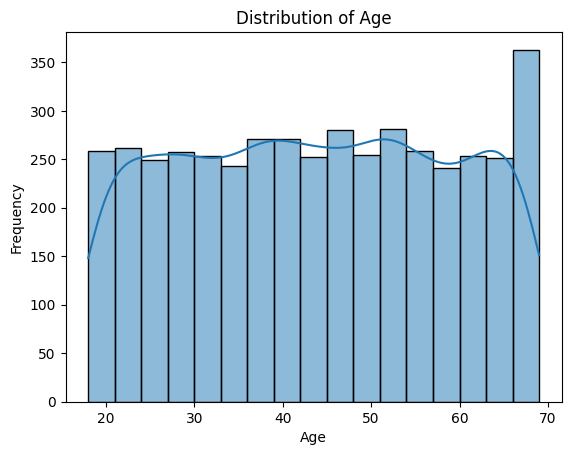

In [40]:
sns.histplot(data=df,kde=True,x=df['Age'].dropna())
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()
#output is multimodal distribution ocording to the histogram from data

Data is not normaly dristibuted so we wll use KNNImputation

In [41]:
from sklearn.impute import KNNImputer, SimpleImputer # for imputing missing values
imputer = KNNImputer(n_neighbors=5) # initialize the imputer with 5 nearest neighbors
df[['Age']] = imputer.fit_transform(df[['Age']]) # impute missing values in the 'Age' column


In [43]:
# Enable experimental feature
from sklearn.experimental import enable_iterative_imputer  

# Import correct class
from sklearn.impute import IterativeImputer  

# Initialize imputer
imputer = IterativeImputer()

# Apply on column
df[['Age']] = imputer.fit_transform(df[['Age']])

In [ ]:
df.isna().mean()*100

In [ ]:
sns.histplot(data=df,kde=True,x=df['Age'].dropna())
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

In [ ]:
df.head() # prints the first 5 rows of the DataFrame
df['Satisfaction_Score'].value_counts() # prints the count of each unique value in the 'Satisfaction_Score' column

Satisfaction_Score
6.0     477
4.0     469
10.0    467
7.0     463
1.0     450
8.0     449
9.0     443
2.0     439
5.0     436
3.0     407
Name: count, dtype: int64